# Visualization and Analysis

This notebook visualizes clustering results to better understand patterns in public space safety.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage

place_data = pd.read_csv("data/clustered_data.csv")

## Cluster Visualization

Scatter plots are used to visualize how public places are grouped based on safety scores.

## Dendrogram Analysis

Dendrograms help visualize hierarchical clustering and relationships between different locations.

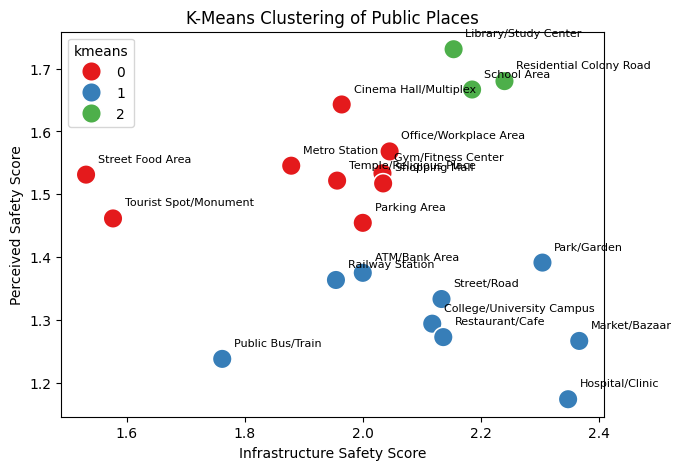

In [12]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x=place_data['Infrastructure_Score'],
    y=place_data['Perception_Score'],
    hue=place_data['kmeans'],
    palette='Set1',
    s=200
)

for i,row in place_data.iterrows():
    plt.text(row['Infrastructure_Score']+0.02,
             row['Perception_Score']+0.02,
             row['Type_of_Public_Place'],
             fontsize=8)

plt.title("K-Means Clustering of Public Places")
plt.xlabel("Infrastructure Safety Score")
plt.ylabel("Perceived Safety Score")
plt.show()

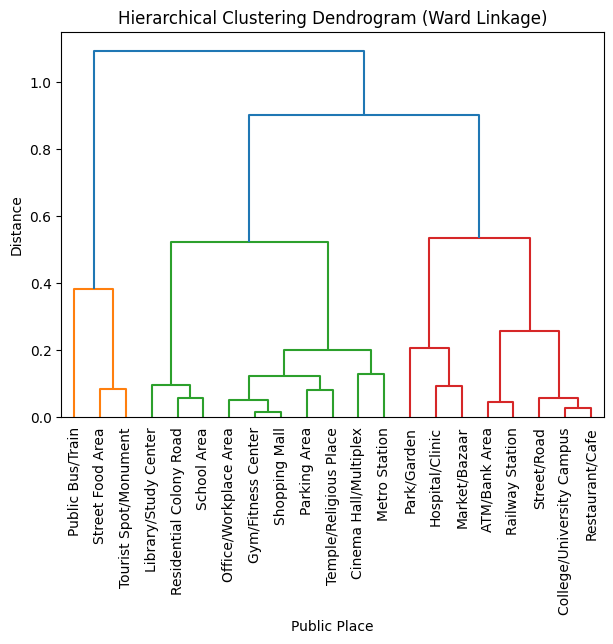

In [13]:
linked = linkage(
    place_data[['Infrastructure_Score','Perception_Score']],
    method='ward'
)

plt.figure(figsize=(7,5))
dendrogram(
    linked,
    labels=place_data['Type_of_Public_Place'].values,
    leaf_rotation=90
)

plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Public Place")
plt.ylabel("Distance")
plt.show()

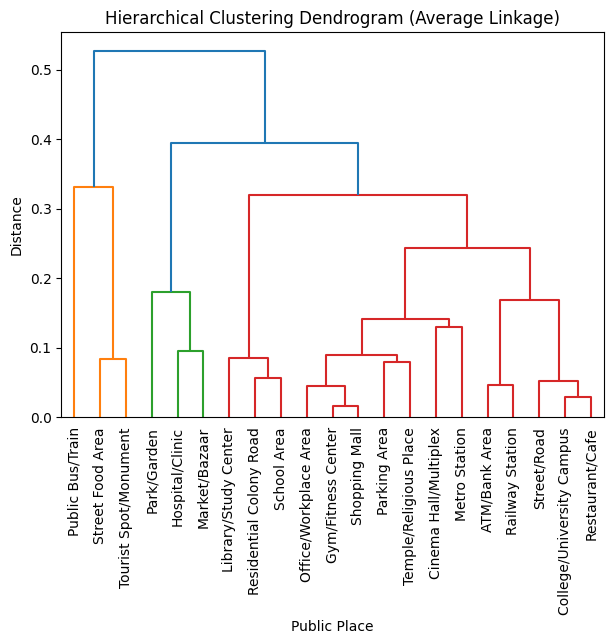

In [11]:
linked_avg = linkage(
    place_data[['Infrastructure_Score','Perception_Score']],
    method='average'
)

plt.figure(figsize=(7,5))
dendrogram(
    linked_avg,
    labels=place_data['Type_of_Public_Place'].values,
    leaf_rotation=90
)

plt.title("Hierarchical Clustering Dendrogram (Average Linkage)")
plt.xlabel("Public Place")
plt.ylabel("Distance")
plt.show()

## Final Cluster Analysis

The final clusters are visualized to interpret safety levels across different public places.

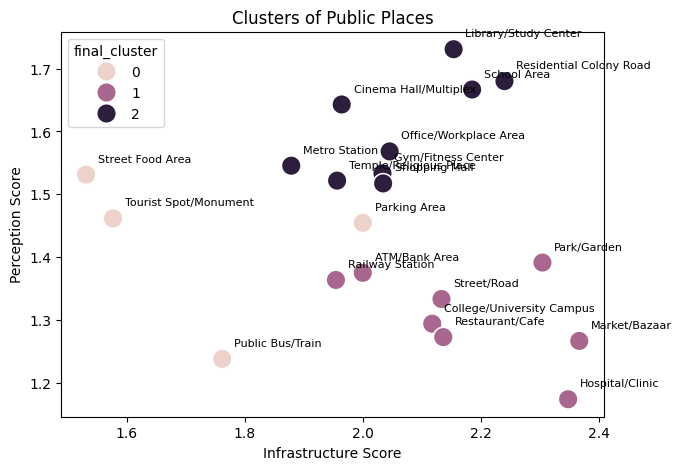

In [8]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x='Infrastructure_Score',
    y='Perception_Score',
    hue='final_cluster',
    s=200,
    data=place_data
)

for i,row in place_data.iterrows():
    plt.text(
        row['Infrastructure_Score']+0.02,
        row['Perception_Score']+0.02,
        row['Type_of_Public_Place'],
        fontsize=8
    )

plt.title("Clusters of Public Places")
plt.xlabel("Infrastructure Score")
plt.ylabel("Perception Score")
plt.show()

## Safety Score Comparison

Bar charts are used to compare safety scores across public places, highlighting safer and less safe areas.

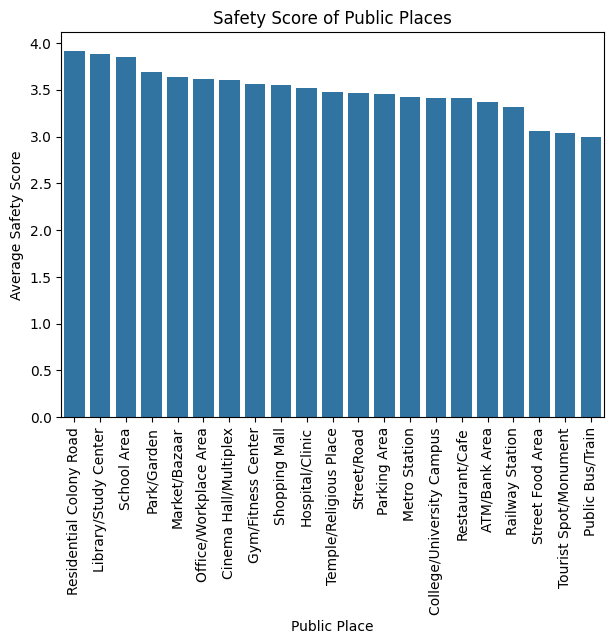

In [10]:
place_safety = place_data.sort_values(by='Safety_Score',ascending=False)

plt.figure(figsize=(7,5))

sns.barplot(
    x='Type_of_Public_Place',
    y='Safety_Score',
    data=place_safety
)

plt.xticks(rotation=90)

plt.title("Safety Score of Public Places")
plt.xlabel("Public Place")
plt.ylabel("Average Safety Score")

plt.show()